# RANSAC Empirical Analysis
**CS5008 Final Project — Arsh Singh**

This notebook runs all three experiments and generates plots for the report.


## TABLE OF CONTENT

- [Setup](#setup)
- [Experiment 01 — Time vs k](#experiment-01)
- [Experiment 02 — Time vs epsilon](#experiment-02)
- [Experiment 03 — Time vs threshold](#experiment-03)
- [Experiment 1 — Outlier Fraction](#experiment-1)
- [Experiment 2 — Structural Bias](#experiment-2)
- [Experiment 3 — Model Degree](#experiment-3)


---
## 1. Setup and Imports <a id="setup"></a>

In [1]:
import sys
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# plot style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# output directory for saved figures
import os
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = 'results'
os.makedirs(DATA_DIR, exist_ok=True)

# Column rename dictionary shared across all three experiments.
# Apply with: df.rename(columns=COL_NAMES, inplace=True)

COL_NAMES = {
    'index':       'Run Index',
    'n':           'Total Points (N)',
    'epsilon':     'Outlier Fraction (ε)',
    'd':           'Expected Inliers (d)',
    'm':           'Model Parameters (m)',
    'k':           'Iterations Used (k)',
    'k_budget':    'Iteration Budget (k)',
    'k_theory':    'Iterations Required by Theory',
    't':           'Inlier Threshold (t)',
    'pr':          'Bias Probability (pr)',
    'bias_type':   'Bias Type',
    'repeat':      'Repeat Number',
    'time_mu_s':   'Wall-Clock Time (μs)',
    'model_error': 'Model Error (Euclidean)',
}
print('Setup complete.')

Setup complete.


---
## Experiment 01: Does wall-clock time grow linearly with k? <a id="experiment-01"></a>
 *     Fixes epsilon = 0.5. Varies k from 10 to 500 in steps of 10.
 *     Runs for linear (m = 2) and quadratic (m = 3) models.
 *     N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [2]:
df01 = pd.read_csv(f"{DATA_DIR}/exp1.csv")
df01.rename(columns=COL_NAMES, inplace=True)
df01.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.5,500,2,10,1.0594,0,210.0,0.808066
1,1,1000,0.5,500,2,10,1.0168,1,242.0,0.252844
2,2,1000,0.5,500,2,10,0.9687,2,225.0,0.362596
3,3,1000,0.5,500,2,10,1.0216,3,217.0,0.108802
4,4,1000,0.5,500,2,10,0.9966,4,211.0,0.075827


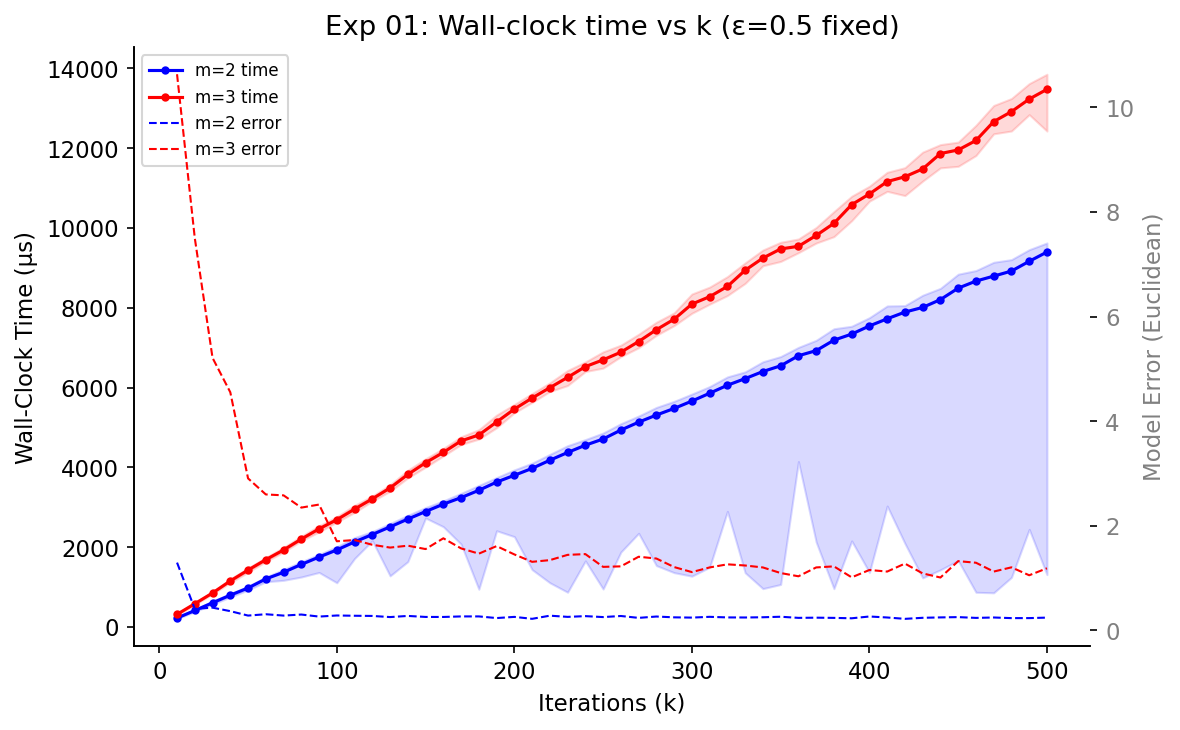

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

for m, color in [(2, "blue"), (3, "red")]:
    sub = df01[df01["Model Parameters (m)"] == m]
    grp = sub.groupby("Iterations Used (k)")["Wall-Clock Time (μs)"]
    means = grp.median()
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("Iterations Used (k)")["Model Error (Euclidean)"]
    ax2.plot(grp2.mean().index, grp2.mean().values,
             color=color, linestyle="--", linewidth=1, label=f"m={m} error")

ax1.set_xlabel("Iterations (k)")
ax1.set_ylabel("Wall-Clock Time (μs)")
ax2.set_ylabel("Model Error (Euclidean)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("Exp 01: Wall-clock time vs k (ε=0.5 fixed)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp1.png", dpi=150)
plt.show()

---

## Experiment 2: Does wall-clock time grow with epsilon for fixed k? <a id="experiment-02"></a>
 *     Fixes k at the value computed for epsilon = 0.5. Varies epsilon
 *     from 0.05 to 0.95 in steps of 0.05. Runs for linear (m = 2) and
 *     quadratic (m = 3) models. N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [4]:
df02 = pd.read_csv(f"{DATA_DIR}/exp2.csv")
df02.rename(columns=COL_NAMES, inplace=True)
df02.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.05,950,2,17,0.9844,0,369.0,0.075866
1,1,1000,0.05,950,2,17,0.9949,1,405.0,0.033580
2,2,1000,0.05,950,2,17,0.9855,2,381.0,0.069295
3,3,1000,0.05,950,2,17,1.0042,3,367.0,0.097331
4,4,1000,0.05,950,2,17,0.9705,4,376.0,0.053030


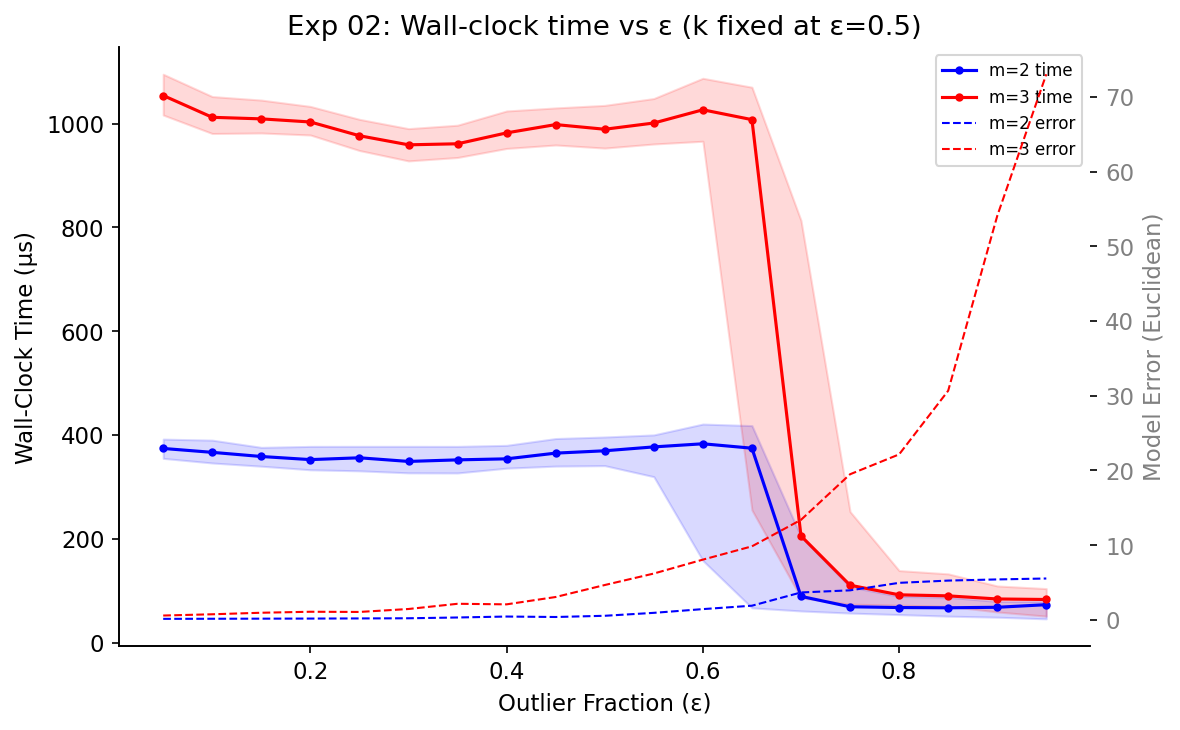

In [17]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

for m, color in [(2, "blue"), (3, "red")]:
    sub = df02[df02["Model Parameters (m)"] == m]
    grp = sub.groupby("Outlier Fraction (ε)")["Wall-Clock Time (μs)"]
    means = grp.median()
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("Outlier Fraction (ε)")["Model Error (Euclidean)"]
    ax2.plot(grp2.mean().index, grp2.mean().values,
             color=color, linestyle="--", linewidth=1, label=f"m={m} error")

ax1.set_xlabel("Outlier Fraction (ε)")
ax1.set_ylabel("Wall-Clock Time (μs)")
ax2.set_ylabel("Model Error (Euclidean)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("Exp 02: Wall-clock time vs ε (k fixed at ε=0.5)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp2.png", dpi=150)
plt.show()

### Observations
* Early stopping kicks in after eps = 0.5

---

## Experiment 3: Does wall-clock time vary with inlier threshold t? <a id="experiment-03"></a>
 *     Fixes k at the value computed for epsilon = 0.5 and fixes
 *     epsilon = 0.5. Varies t as a multiplier of noise_std from 0.5
 *     to 5.0 in steps of 0.5. Runs for linear (m = 2) and quadratic
 *     (m = 3) models. N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [6]:
df03 = pd.read_csv(f"{DATA_DIR}/exp3.csv")
df03.rename(columns=COL_NAMES, inplace=True)
df03.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),t_multiplier,Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.5,500,2,17,0.25,0.5,0,290.0,0.772633
1,1,1000,0.5,500,2,17,0.25,0.5,1,295.0,0.628086
2,2,1000,0.5,500,2,17,0.25,0.5,2,290.0,0.584601
3,3,1000,0.5,500,2,17,0.25,0.5,3,296.0,0.655644
4,4,1000,0.5,500,2,17,0.25,0.5,4,303.0,0.168538


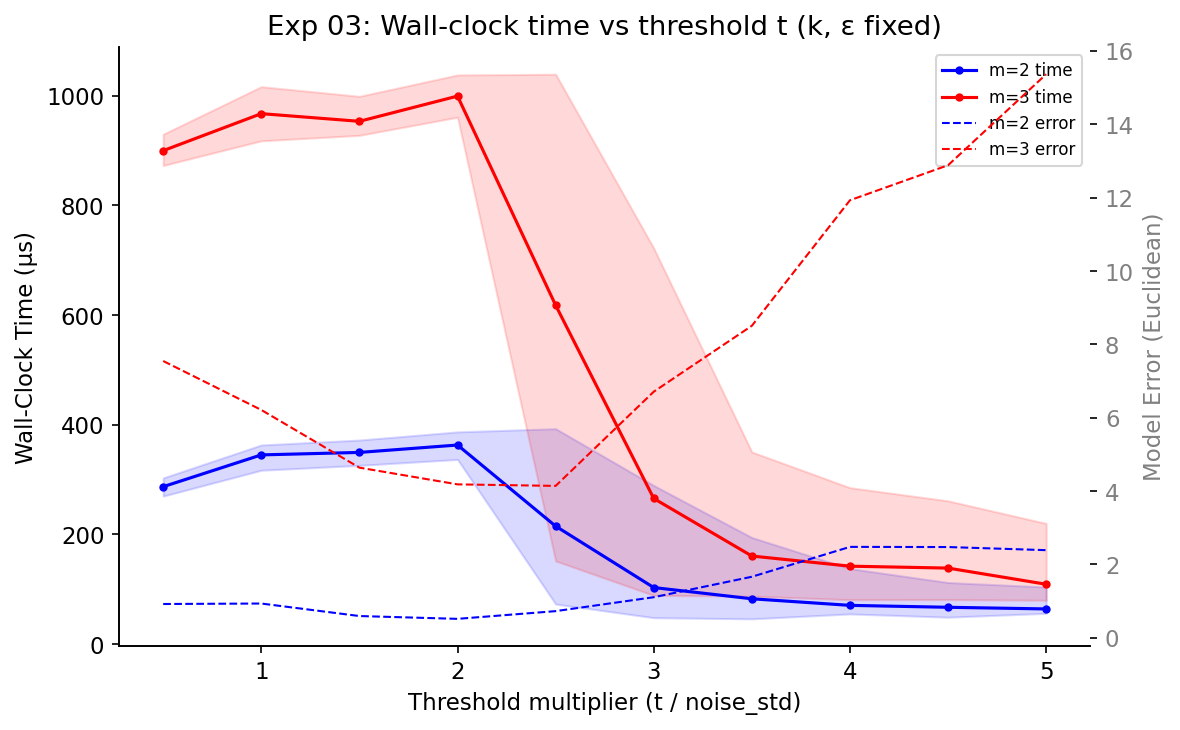

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

for m, color in [(2, "blue"), (3, "red")]:
    sub = df03[df03["Model Parameters (m)"] == m]
    grp = sub.groupby("t_multiplier")["Wall-Clock Time (μs)"]
    means = grp.median()
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("t_multiplier")["Model Error (Euclidean)"]
    ax2.plot(grp2.mean().index, grp2.mean().values,
             color=color, linestyle="--", linewidth=1, label=f"m={m} error")

ax1.set_xlabel("Threshold multiplier (t / noise_std)")
ax1.set_ylabel("Wall-Clock Time (μs)")
ax2.set_ylabel("Model Error (Euclidean)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("Exp 03: Wall-clock time vs threshold t (k, ε fixed)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp3.png", dpi=150)
plt.show()

### Observation: 
* Since we have kept noise at 2, for small t up to 2, even true inliers may fall outside the threshold due to noise — so RANSAC struggles to find d inliers and runs many iterations before succeeding or exhausting k. That's the slow region.
* Beyond multiplier 2, the threshold is so wide that outliers start counting as inliers too, inflating the consensus set size past d quickly and triggering early stopping — hence the drop.

---

## Experiment 4: How does RANSAC break down as outlier fraction increases?
 *     Fixes k at the value computed for epsilon = 0.5 and varies epsilon
 *     from 0.1 to 0.9 in steps of 0.1. Runs for linear (m = 2) and
 *     quadratic (m = 3) models. N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [8]:
df4 = pd.read_csv('results/exp4.csv').rename(columns=COL_NAMES)
df4.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.05,950,2,17,0.9647,0,366.0,0.043207
1,1,1000,0.05,950,2,17,0.9958,1,365.0,0.092354
2,2,1000,0.05,950,2,17,0.9883,2,367.0,0.165092
3,3,1000,0.05,950,2,17,0.9481,3,364.0,0.046007
4,4,1000,0.05,950,2,17,1.0219,4,378.0,0.141204


In [9]:
agg4 = (df4.groupby(['Model Parameters (m)', 'Outlier Fraction (ε)'])
           ['Model Error (Euclidean)']
           .agg(mean_error='mean', std_error='std', count='count')
           .reset_index())

In [10]:
# breakdown threshold — model error greater than twice noise std
BREAKDOWN_THRESHOLD = 2 * 0.5   # 2 * NOISE_STD

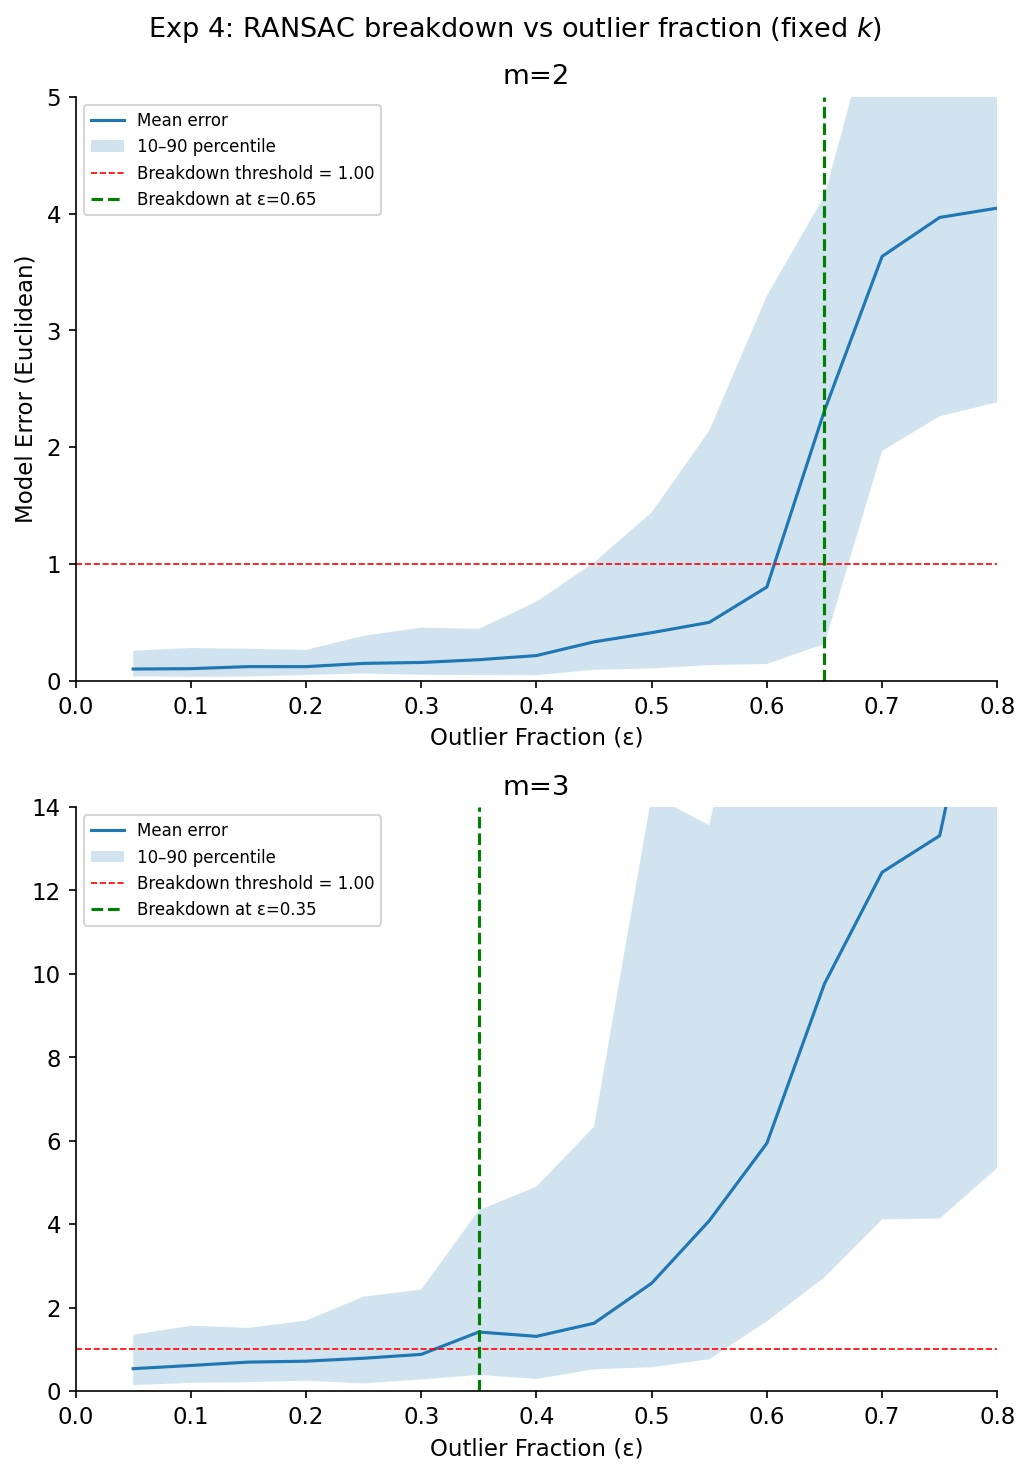

Breakdown threshold: 1.0
  m=2: breakdown at ε=0.6
  m=3: breakdown at ε=0.25


In [19]:
BREAKDOWN_THRESHOLD = 2 * 0.5  # 2 * NOISE_STD

models = df4["Model Parameters (m)"].unique()
fig, axes = plt.subplots(len(models), 1, figsize=(7, 10))

for i, m in enumerate(models):
    ax = axes[i]
    sub = df4[df4["Model Parameters (m)"] == m]
    grp = sub.groupby("Outlier Fraction (ε)")["Model Error (Euclidean)"]

    means = grp.median()
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    breakdown_rows = means[means > BREAKDOWN_THRESHOLD]
    breakdown_eps = breakdown_rows.index[0] if not breakdown_rows.empty else None

    ax.plot(means.index, means.values, label="Mean error")
    ax.fill_between(means.index, lower, upper, alpha=0.2, label="10–90 percentile")
    ax.axhline(BREAKDOWN_THRESHOLD, color="red", linestyle="--",
               linewidth=0.8, label=f"Breakdown threshold = {BREAKDOWN_THRESHOLD:.2f}")

    if breakdown_eps is not None:
        ax.axvline(x=breakdown_eps, color="green", linestyle="--",
                   label=f"Breakdown at ε={breakdown_eps:.2f}")

    ax.set_title(f"m={m}")
    ax.set_xlabel("Outlier Fraction (ε)")
    ax.set_xlim(0, 0.8)
    if i == 0:
        ax.set_ylim(0, 5)
    else:
        ax.set_ylim(0, 14)
    if i == 0:
        ax.set_ylabel("Model Error (Euclidean)")
    ax.legend(fontsize=8)

plt.suptitle("Exp 4: RANSAC breakdown vs outlier fraction (fixed $k$)",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp4.png", dpi=150)
plt.show()

print(f"Breakdown threshold: {BREAKDOWN_THRESHOLD}")
for m in models:
    sub = df4[df4["Model Parameters (m)"] == m]
    grp = sub.groupby("Outlier Fraction (ε)")["Model Error (Euclidean)"].mean()
    breakdown_rows = grp[grp > BREAKDOWN_THRESHOLD]
    eps = breakdown_rows.index[0] if not breakdown_rows.empty else "none"
    print(f"  m={m}: breakdown at ε={eps}")

--- 

## Experiment 5: At what structural bias probability does RANSAC fail?
 *      Fixes epsilon = 0.3 and varies pr from 0.0 to 1.0 in steps of 0.05.
 *      Runs for three bias types: constant, linear, periodic.
 *      Runs for linear (m = 2) and quadratic (m = 3) models.
 *      N_TOTAL = 1000 is fixed throughout.
 *      Repeats N_REPEATS times per condition.

In [12]:
df5 = pd.read_csv('results/exp5.csv').rename(columns=COL_NAMES)
df5.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Bias Probability (pr),Bias Type,Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.1,900,2,17,1.0182,0.0,constant,0,317.0,0.051027
1,1,1000,0.1,900,2,17,0.9623,0.0,constant,1,379.0,0.234116
2,2,1000,0.1,900,2,17,0.9715,0.0,constant,2,368.0,0.034366
3,3,1000,0.1,900,2,17,0.9789,0.0,constant,3,367.0,0.079510
4,4,1000,0.1,900,2,17,1.0454,0.0,constant,4,365.0,0.046738


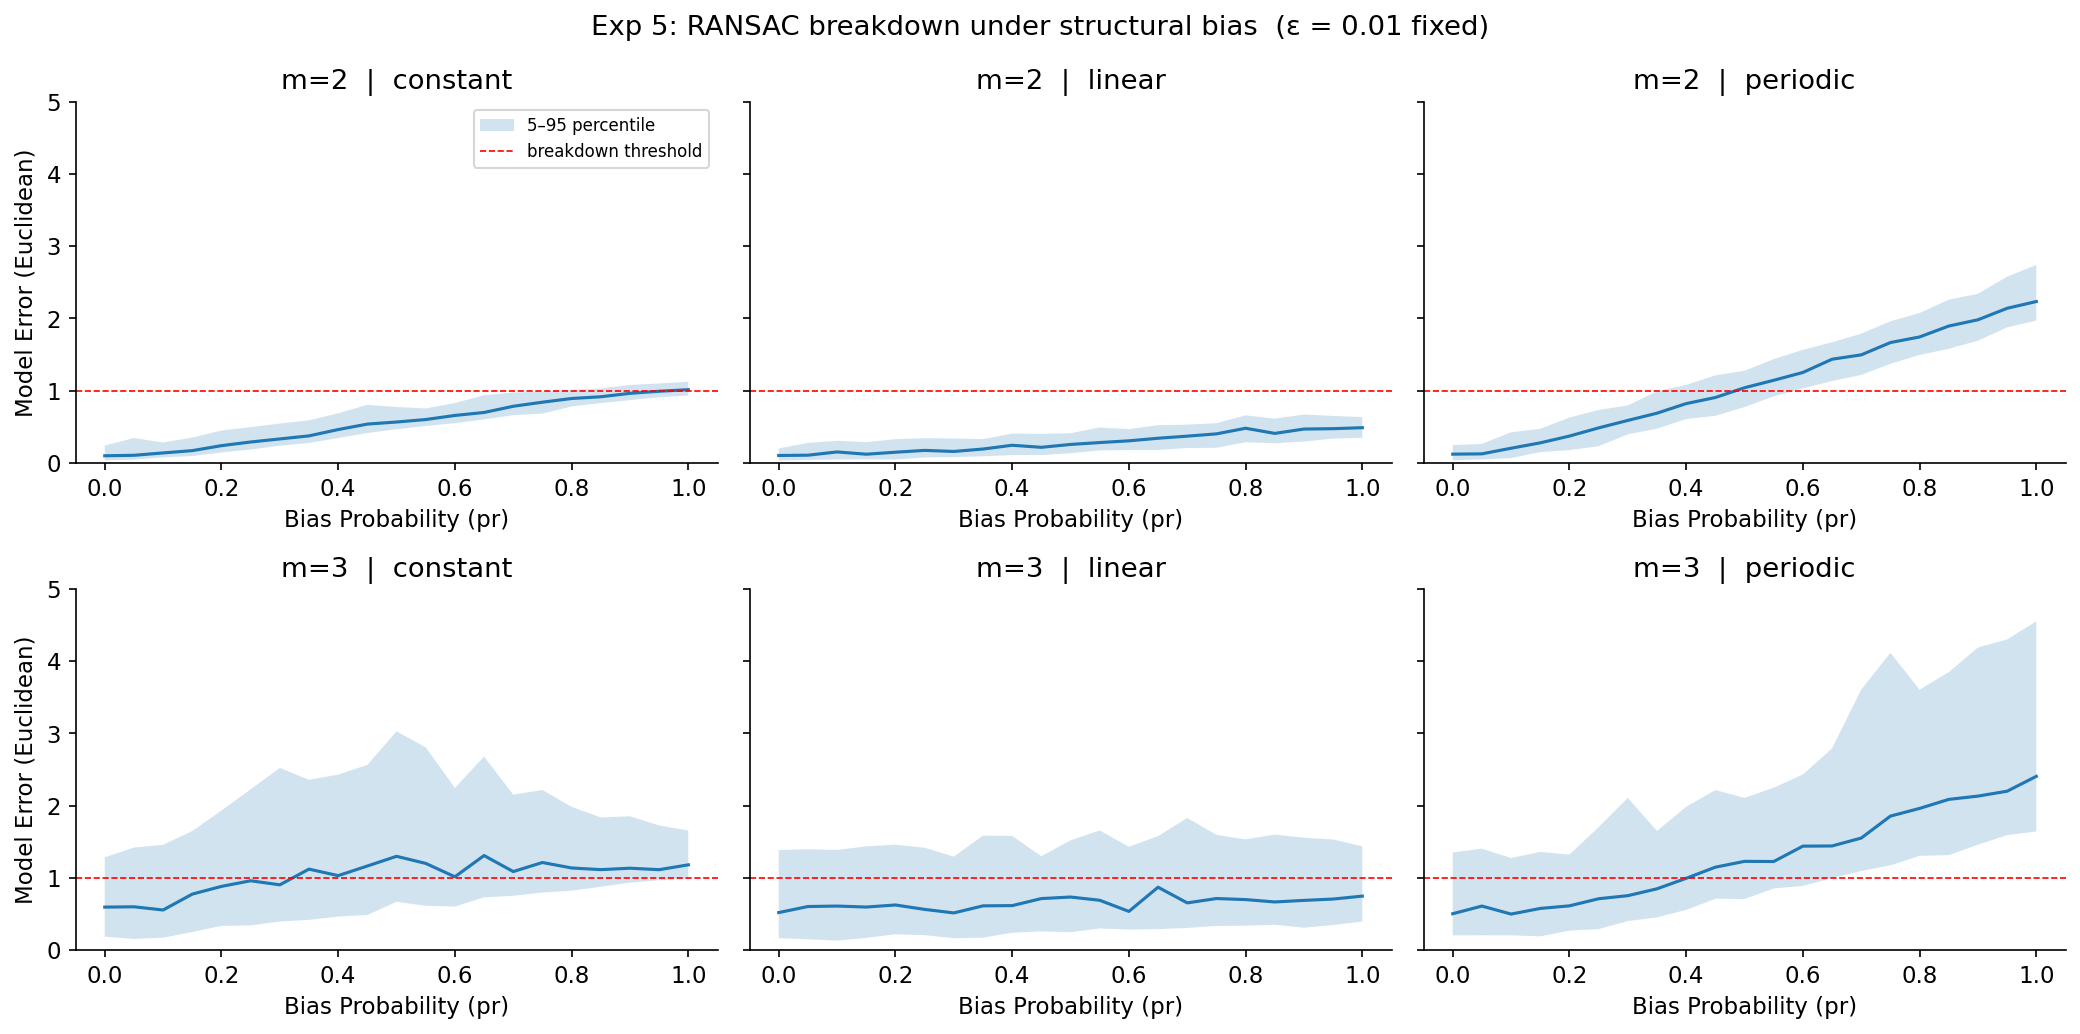

In [20]:
BREAKDOWN_THRESHOLD = 2 * 0.5  # 2 * NOISE_STD

bias_types = df5["Bias Type"].unique()
models     = df5["Model Parameters (m)"].unique()

fig, axes = plt.subplots(len(models), len(bias_types),
                         figsize=(14, 7), sharey=True)

for i, m in enumerate(models):
    for j, bias in enumerate(bias_types):
        ax  = axes[i, j]
        sub = df5[(df5["Model Parameters (m)"] == m) &
                  (df5["Bias Type"] == bias)]
        grp = sub.groupby("Bias Probability (pr)")["Model Error (Euclidean)"]

        means = grp.median()
        lower = grp.quantile(0.10)
        upper = grp.quantile(0.90)

        ax.plot(means.index, means.values)
        ax.fill_between(means.index, lower, upper, alpha=0.2, label='5–95 percentile')
        ax.axhline(BREAKDOWN_THRESHOLD, color='red', linestyle='--',
                   linewidth=0.8, label='breakdown threshold')

        ax.set_title(f"m={m}  |  {bias}")
        ax.set_xlabel("Bias Probability (pr)")
        ax.set_ylim(0, 5)
        if j == 0:
            ax.set_ylabel("Model Error (Euclidean)")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle("Exp 5: RANSAC breakdown under structural bias  (ε = 0.01 fixed)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp5.png", dpi=150)
plt.show()

### Observations:

Linear Model:
1. In presense of constant bias, RANSAC does not break down at any pr.
2. In presense of linear bias, RANSAC can recover true model at modest bias with all pr.
3. In presence of periodic bias again, RANSAC breaksdown at mediocre amounts of bias at pr ~0.5.

Quadratic Model:
1. In presense of constant bias the breakdown happens at pr = 0.3
2. With linear bias, there is no break-down.
3. In presence of periodic bias, RANSAC breaks down after modest amount of bias at pr ~0.4.

---
## Experiment 6 — At What Model Degree Does RANSAC Fail for a Budgeted or Fixed Iteration Count? <a id="experiment-3"></a>

Fix $\varepsilon = 0.1$. Vary $m$ from 2 to 8 in steps of 1. Run twice for $k$ = 100 and $k$ = 1000. `N` is 1000. Repeat 100 times.


In [14]:
df6 = pd.read_csv('results/exp6.csv').rename(columns=COL_NAMES)
df6.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iteration Budget (k),Iterations Required by Theory,Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.5,500,3,100,35,1.0105,0,2792.0,3.219082
1,1,1000,0.5,500,3,100,35,1.0195,1,2804.0,5.090563
2,2,1000,0.5,500,3,100,35,1.0201,2,2864.0,0.397420
3,3,1000,0.5,500,3,100,35,0.9536,3,2767.0,3.269255
4,4,1000,0.5,500,3,100,35,0.9896,4,2806.0,0.765701


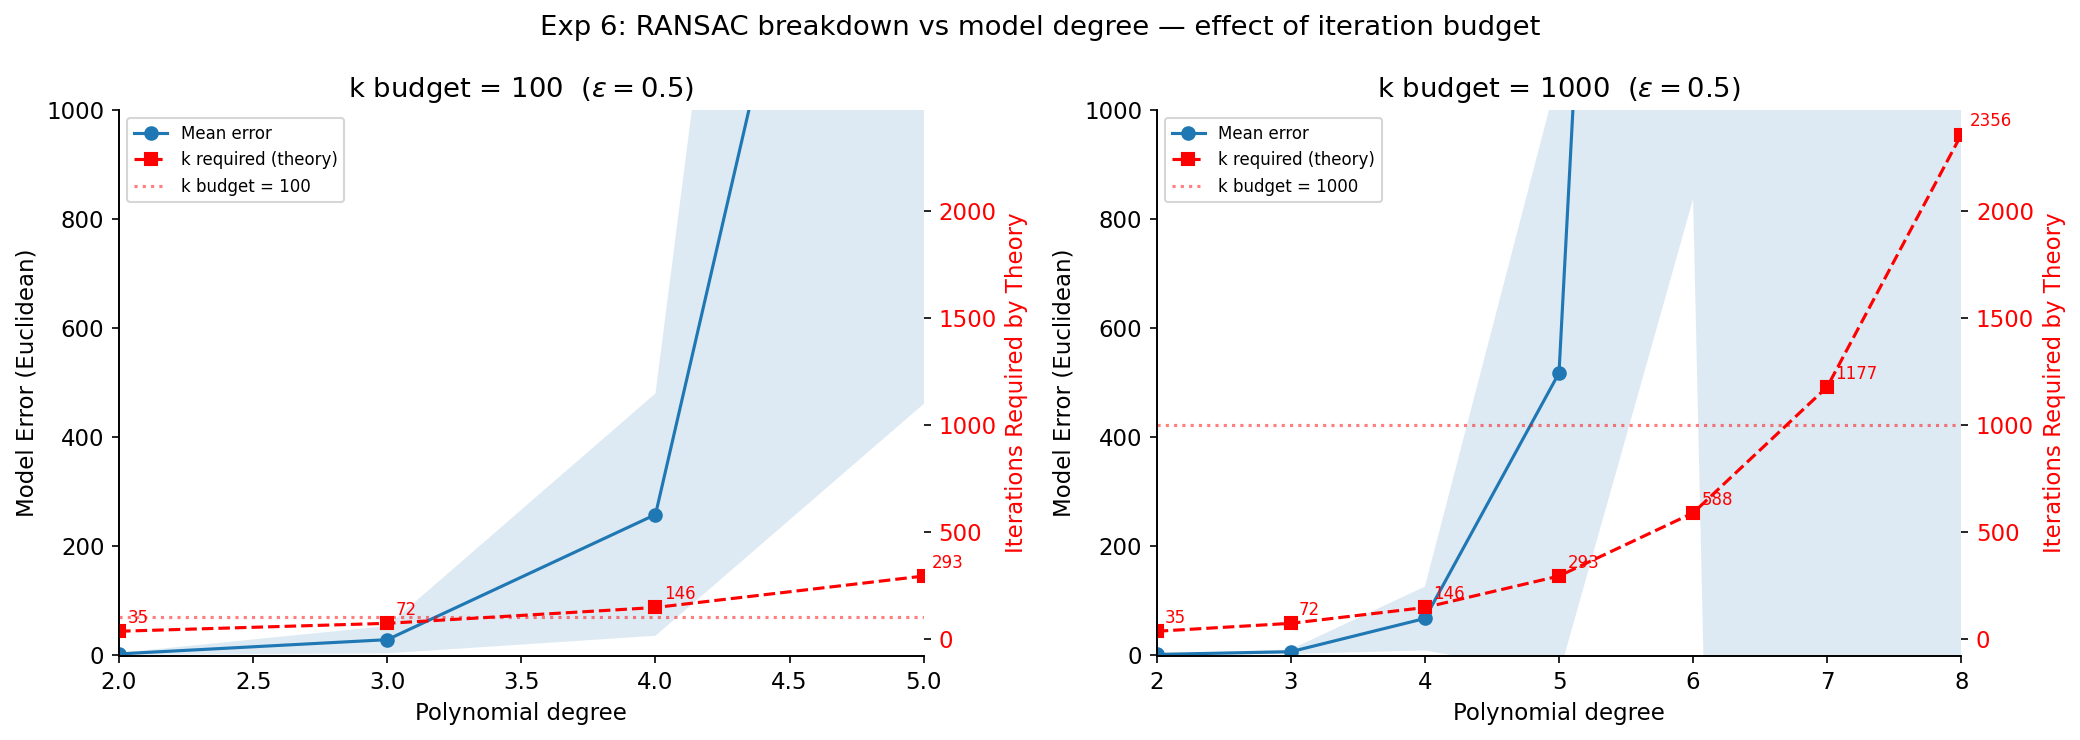

In [15]:
df6["degree"] = df6["Model Parameters (m)"] - 1
sub100  = df6[df6["Iteration Budget (k)"].astype(int) == 100]
sub1000 = df6[df6["Iteration Budget (k)"].astype(int) == 1000]

agg100  = (sub100.groupby("degree")["Model Error (Euclidean)"]
                  .agg(mean_error="mean", std_error="std")
                  .reset_index())
agg1000 = (sub1000.groupby("degree")["Model Error (Euclidean)"]
                   .agg(mean_error="mean", std_error="std")
                   .reset_index())

agg_theory = (sub100.groupby("degree")["Iterations Required by Theory"]
                     .first().reset_index())
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
# fig, (ax_l, ax_r) = plt.subplots(2, 1, figsize=(7, 10))

for ax1, agg, k_budget in [(ax_l, agg100, 100), (ax_r, agg1000, 1000)]:
    ax2 = ax1.twinx()

    ax1.plot(agg["degree"], agg["mean_error"],
             marker="o", label="Mean error")
    ax1.fill_between(agg["degree"],
                     agg["mean_error"] - agg["std_error"],
                     agg["mean_error"] + agg["std_error"],
                     alpha=0.15)

    ax2.plot(agg_theory["degree"],
             agg_theory["Iterations Required by Theory"],
             marker="s", color="red", linestyle="--",
             label="k required (theory)")
    for _, row in agg_theory.iterrows():
        ax2.annotate(f"{int(row['Iterations Required by Theory'])}",
                     xy=(row["degree"], row["Iterations Required by Theory"]),
                     xytext=(4, 4), textcoords="offset points",
                     color="red", fontsize=8)
    ax2.axhline(k_budget, color="red", linestyle=":",
                alpha=0.5, label=f"k budget = {k_budget}")
    ax2.tick_params(axis='y', labelcolor='red')
    ax1.set_xlabel("Polynomial degree")
    ax1.set_ylabel("Model Error (Euclidean)")
    ax2.set_ylabel("Iterations Required by Theory", color="red")
    ax1.set_title(f"k budget = {k_budget}  ($\\varepsilon=0.5$)")
    ax1.set_ylim(-2, 1000)
    if k_budget == 100:
        ax1.set_xlim(2, 5)
    else:
        ax1.set_xlim(2, 8)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", fontsize=8)
    #ax1.set_ylim(0, 10)

plt.suptitle("Exp 6: RANSAC breakdown vs model degree — effect of iteration budget")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp6.png", dpi=150)
plt.show()


### Observations
* At m = 4 the model error is ~500 model errors  for k budget of 100 and ~ 100 model errors. This breakdown is not due to $k$. Something else is going on. 